# Building Distributions

The purpose of this notebook is to build some canonical distributions used for convergence testing. 
These include
- normal distribution
- geometric distribution
- binomial distribution


In [1]:
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tabulate import tabulate



We begin by building a normal distribution 
$$
 X \sim N(0, 2)
$$

Where we want to estimate this quantity 
$$
E(X^2)
$$

using $N$ samples $X_1, \ldots, X_N$ and estimator:

$$
\mu_N  = \frac{1}{N} \sum_{i=1}^N X_i^2
$$

**The theory**

Here is to see that the standard error of this MC method estimator is proportional to the inverse square root of the number of samples taken from the distribution.

\begin{align*}
    SE \propto \frac{1}{\sqrt{N}}
\end{align*}



(array([1., 0., 1., 0., 3., 0., 2., 1., 1., 1.]),
 array([-5.92905768, -4.85206891, -3.77508014, -2.69809137, -1.6211026 ,
        -0.54411383,  0.53287494,  1.60986371,  2.68685248,  3.76384125,
         4.84083002]),
 <BarContainer object of 10 artists>)

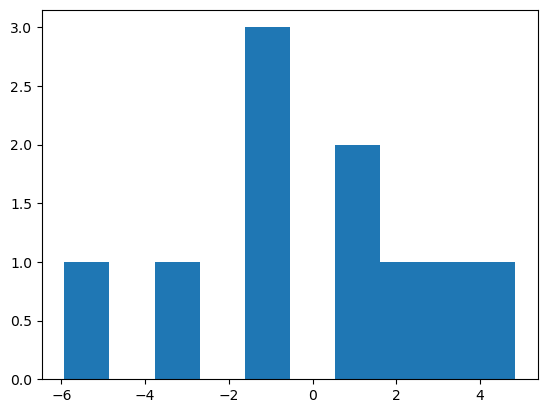

In [ ]:
# building a distribution:

# seeding
rng = np.random.default_rng(seed=42)

# get an array of norm rnds
# generate N samples:
N = 10
sigma = 2.0
true_mean = 0.0
X = rng.normal(loc=true_mean, scale=sigma, size=N)

# make normal distro. check with plot
plt.hist(rnd_array)


# Build an Estimator


In [2]:
# lets build estimator for quantity E(X^2).

# for a X~N(0, 2), we get 4? Var(X) = E(X^2) - E(X)^2 = E(X^2) = 4. 


# to build the estimator design it:
# seeding
rng = np.random.default_rng(seed=42)

# Distribution Params.
sigma = 2.0
true_mean = 0.0

exact_solution = sigma ** 2

# Build out estimator means.

# Storing data.
estimator_mean = []
estimator_sdev = []
estimator_rmse = []
error_abs_mean = []
runtime_mean = []

# Executing Loop. 
log_sample_size = [10 ** i for i in range(1, 7)]
repeat_draw_size = 100
repeat_draws = range(1, repeat_draw_size + 1) # Doing 1 draw per sample size is noisy. Make several draws.
for sample_size in log_sample_size:
    # Storing data per sample size.
    estimator = []
    error_abs = []
    runtime = []
    # Get repeated draws for this sample size.
    for draw in repeat_draws:
        time_start = time.perf_counter()

        # Draw the random numbers.
        X = rng.normal(loc=true_mean, scale=sigma, size=sample_size)

        # Calculate QOIs.
        mu_n = sum([x ** 2 for x in X]) / sample_size
        estimator.append(mu_n)
        error_abs.append(abs(mu_n - exact_solution))

        time_end = time.perf_counter()
        runtime.append(time_end - time_start)
    
    # Calculate mean of estimates at this sample size.
    estimator_mean.append(sum(estimator) / repeat_draw_size)
    error_abs_mean.append(sum(error_abs) / repeat_draw_size)
    runtime_mean.append(sum(runtime) / repeat_draw_size)

    # Compute stan dev of estimates.
    # This is a biased estimator of stan dev but for large sample size (repeat_draw_size), the difference is negligible.
    estimator_sdev_ = np.sqrt(sum([(x - estimator_mean[-1]) ** 2 for x in estimator]) / (repeat_draw_size - 1))
    estimator_rmse_ = np.sqrt(sum([(exact_solution - y_hat) ** 2 for y_hat in estimator])) / repeat_draw_size
    estimator_sdev.append(estimator_sdev_)
    estimator_rmse.append(estimator_rmse_)




best_fit_slope: -0.5037828366284032


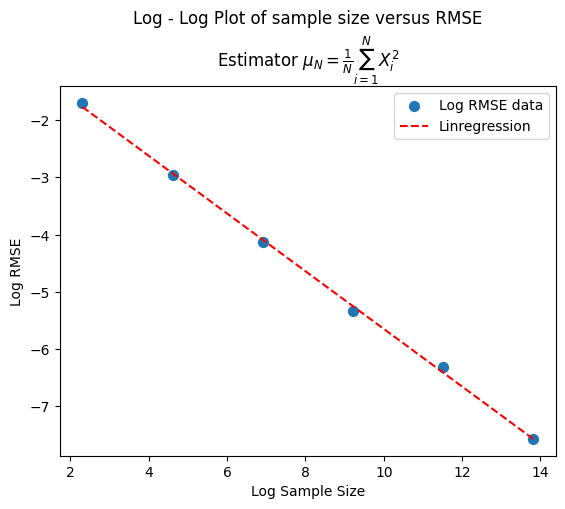

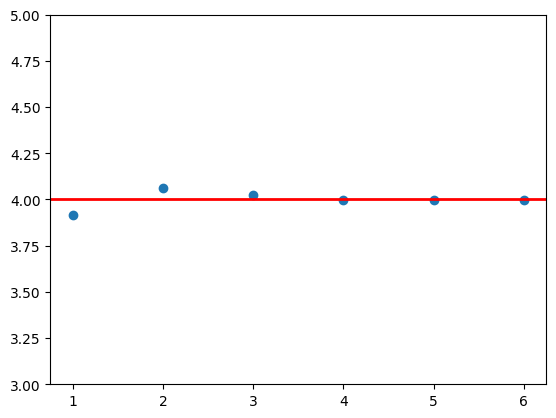

In [10]:
# Compare against Theory

# MC theory says:
# Error proportional to 1/sqrt(N)

# Get Best Fit line.
# Using estimated output data, estimate the fit.
from numpy.polynomial import Polynomial

x_data = np.log(log_sample_size)
y_data = np.log(estimator_rmse)
best_fit_line = Polynomial.fit(x_data, y_data, deg=1)

y_intercept, best_fit_slope = best_fit_line.convert().coef
print(f"best_fit_slope: {best_fit_slope}")

# Plot the RMSE and the best fit line.
plt.figure()
plt.scatter(x_data, y_data, s=50, label="Log RMSE data");
plt.plot(x_data, list(map(lambda x: best_fit_slope * x + y_intercept, x_data)), color="red", linestyle="--", label="Linregression");

plt.title("Log - Log Plot of sample size versus RMSE" "\n" r"Estimator $\mu_N  = \frac{1}{N} \sum_{i=1}^N X_i^2$");
plt.ylabel("Log RMSE");
plt.xlabel("Log Sample Size");
plt.legend();


# Plot the actual values compared to the mean. 
plt.figure()
x_space = [np.log10(x) for x in log_sample_size]
plt.scatter(x_space, estimator_mean);
plt.axhline(y=sigma ** 2, color="red", linestyle="-", linewidth=2);
# plt.xlim(0, 5)
plt.ylim(3, 5);

# Extension 1: Antithetic Variate

Let's build an antithetic variate and perform a similar comparison. 

Given that $X \sim N(0,2)$ and we are estimating $\theta = E(X^2)$ using $\hat{\theta} = \frac{1}{M} \sum_{i=1}^M X_i^2$.

Suppose we use the *biased* estimator:

$$ \hat{\theta}_A = \frac{1}{2M} \sum_{i=1}^{2M} u_i^2 $$

where 

$u = \{ u_1, u_2, \ldots, u_M, \ldots u_{2M} \}$ and $u_i \sim N(0, 2).$

We can build the antithetic variate as follows:

\begin{align*}
    u' &= \{ \pm u_1', \pm u_2', \ldots, \pm u_M' \}
    \Rightarrow \\[3ex]
    \hat{\theta}_B &= \frac{1}{2M} \left( \sum_{i=1}^M (u_i')^2 + \sum_{i=1}^M (-u_i')^2\right) \\[3ex]
    &= \frac{1}{2M} \left( \sum_{i=1}^M (u_i')^2 + \sum_{i=1}^M (u_i')^2\right) \\[3ex]
    &= \frac{1}{M} \sum_{i=1}^M (u_i')^2 
\end{align*}

We should expect to see no gain here from the antithetic variant of the estimator because of this symmetry of $f(U) = f(-U)$. 




## Build the Antithetic Estimator

In [302]:
# lets build estimator for quantity E(X^2).

# for a X~N(0, 2), we get 4? Var(X) = E(X^2) - E(X)^2 = E(X^2) = 4. 

# to build the estimator design it:
# seeding
rng = np.random.default_rng(seed=42)

# Distribution Params.
sigma = 2.0
true_mean = 0.0

exact_value = sigma ** 2

# Get N numbers. 

# Time to scale up to multiple repeated draws.

# Storing data.
estimator_mean_A = []
estimator_sdev_A = []
estimator_rmse_A = []
error_abs_mean_A = []

estimator_mean_B = []
estimator_sdev_B = []
estimator_rmse_B = []
error_abs_mean_B = []

runtime_mean = []

# Executing loop.
log_sample_size = [10 ** i for i in range(5, 7)]
repeat_draw_size = 100
repeat_draws = range(1, repeat_draw_size)

for M in log_sample_size:
    # Get estimator A from the same "round".
    estimator_A = []
    estimator_B = []
    error_abs_A = []
    error_abs_B = []

    # Get repeated draws for this sample size.
    for draw in repeat_draws:
        time_start = time.perf_counter()

        # Draw the random numbers.
        u_A = rng.normal(loc=true_mean, scale=sigma, size=(2 * M))
        u_B = rng.normal(loc=true_mean, scale=sigma, size=M)
        u_Bp = np.concatenate((u_B, -u_B))
        
        # Make the estimator.
        mu_A = sum(u_A ** 2) / (2 * M)
        mu_B = sum(u_Bp ** 2) / (2 * M)
        estimator_A.append(mu_A)
        estimator_B.append(mu_B)
        error_abs_A.append(abs(mu_A - exact_value))
        error_abs_B.append(abs(mu_B - exact_value))

        time_end = time.perf_counter()
        runtime.append(time_end)
    
    # Calculate mean of estimates at this sample size.
    estimator_mean_A.append(sum(estimator_A) / repeat_draw_size)
    estimator_mean_B.append(sum(estimator_B) / repeat_draw_size)
    runtime_mean.append(sum(runtime) / repeat_draw_size)

    # Calculate mean of sdev of estimates at this sample size.
    estimator_sdev_A_ = np.sqrt(sum([(x - estimator_mean_A[-1]) ** 2 for x in estimator_A]) / (repeat_draw_size - 1))
    estimator_sdev_B_ = np.sqrt(sum([(x - estimator_mean_B[-1]) ** 2 for x in estimator_B]) / (repeat_draw_size - 1))

    estimator_sdev_A.append(estimator_sdev_A_)
    estimator_sdev_B.append(estimator_sdev_B_)

error_abs_mean_A = np.mean(error_abs_A)
error_abs_mean_B = np.mean(error_abs_B)

theta_A = np.mean(estimator_mean_A)
theta_Bp = np.mean(estimator_mean_B)

print("Estimates")
print(f"theta_A: {theta_A}")
print(f"theta_Bp: {theta_Bp}")
print("Absolute Error")
print(f"E-theta_A_mean: {abs(error_abs_mean_A)}")
print(f"E-theta_B_mean: {abs(error_abs_mean_B)}")

Estimates
theta_A: 3.979757461837644
theta_Bp: 3.97937329892871
Absolute Error
E-theta_A_mean: 0.0032737503800211423
E-theta_B_mean: 0.004592880040185281


## Theory: Antithetic Variate

In the antithetic path reduces the variance of the MC simulation results with the goal of improving the rate of convergence.

https://en.wikipedia.org/wiki/Antithetic_variates

The method is as follows:

Take each sample path and with it, take an antithetic path:

\begin{align*}
    \{ \epsilon_1, \epsilon_2, \ldots, \epsilon_M \} \\
    %
    \{- \epsilon_1, - \epsilon_2, \ldots, -\epsilon_M \} \\
\end{align*}

This technique reduces the number of samples taken to generate $N$ paths.  It also reduces the variance of the sample paths. 


Let us estimate some quantity:

\begin{align*}
    \theta = E\left( h(X) \right) = E(Y)
\end{align*}

Suppose to calculate an estimate we gather two samples $Y_1, Y_2$. An **unbiased** estimator of $\theta$ is:

\begin{align*}
    \hat{\theta} = \frac{Y_1 + Y_2}{2}. 
\end{align*}

We can calculate 

\begin{align*}
    Var(\hat{\theta}) = \frac{Var(Y_1) + Var(Y_2) + 2 Cov(Y_1, Y_2)}{4}
\end{align*}

The first two terms above are always positive, while the covariance can be negative, and maximally so when $Y_1 = -Y_2$.



**One example here is** 

Supose $X \sim U[0,1]$ with one sample: $u = \{u_1, u_2, \ldots, u_M \}$. How would we build the antithetic sample? 

As follows:

\begin{align*}
    u' = \{1 - u_1, 1 - u_2, \ldots, 1 - u_M \}.
\end{align*}

Note that these would satisfy $u' \sim U[0, 1]$ as well.

Now suppose we want to estimate 

$$
I = \int_0^1 \frac{1}{1 + x} dx,
$$

with the exact solution $I = ln(2) \approx 0.69314$.

One way to think about this integral is expected value of $f(U)$ where $U \sim U[0,1]$ and $f(U) = \frac{1}{1 + U}$, and by the definition of expected value:

$$
    E(f(U)) = \frac{1}{1 - 0} \int_0^1 f(U) \cdot 1 \ dU = \frac{1}{1 - 0} \int_0^1 \frac{1}{1 + x} \cdot 1 \ dx
    %

$$

Suppose we then esimate $E(f(U))$ using the unbiased estimate: 

$$\hat{\theta}_A = \hat{E}_A = \frac{1}{2M} \sum_{i = 1}^{2M} \frac{1}{1 + u_i} $$

Given antitetical values $u, u'$, we would estimate 

$$\hat{\theta}_B = \hat{E}_B =  \frac{1}{2M} \left( \sum_{i = 1}^{M} \frac{1}{1 + u_i} + \sum_{i = 1}^{M} \frac{1}{1 + u_i'} \right)$$

Why the $2M$ for calculation $A$? because to compare equal sized samples we have to collect twice as many direct samples for $u$ versus if we use the antithetic sampling, which is free, because we just use what we already have an convert as $u' = 1 - u$.




## Antithetic pre-Buildout

Estimates
theta_A: 0.6950516632392347
theta_Bp: 0.693669216611454
Absolute Error
E-theta_A: 0.0019044826792894431
E-theta_Bp: 0.0005220360515086897


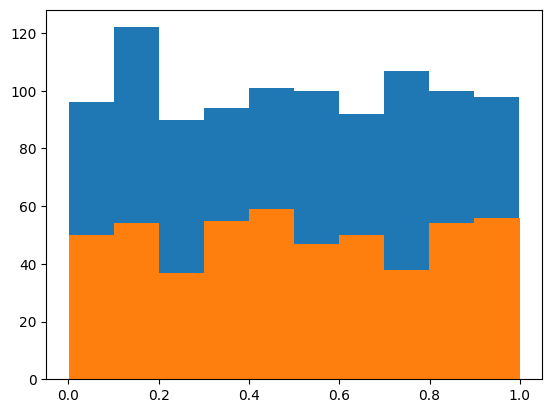

In [114]:
import numpy as np

rng = np.random.default_rng(seed=42)

# Collect sampling and antithetic sample.
M = 500
u_A = rng.uniform(0, 1.0, 2 * M)
u_B = rng.uniform(0, 1.0, M)
u_Bp = np.concatenate((u_B, (1 - u_B)))

# print(u_A)
# print(u_Bp)

plt.hist(u_A);
plt.hist(u_B);
# plt.hist(u_Bp, label="antithetic");

# Build the estimates:

theta_A =  sum(1 / (1 + u_A)) / (2 * M)
theta_Bp = sum(1 / (1 + u_Bp)) / (2 * M)
exact_soln = np.log(2)

print("Estimates")
print(f"theta_A: {theta_A}")
print(f"theta_Bp: {theta_Bp}")
print("Absolute Error")
print(f"E-theta_A: {abs(theta_A - exact_soln)}")
print(f"E-theta_Bp: {abs(theta_Bp - exact_soln)}")

# Extension 2: Control Variates

## Build the Control Variate Estimator

In [ ]:
# lets build estimator for quantity E(X^2).

# X ~ N(0, 2) 

# Estimate E(X^2)

# unknown mu = E(X^2)

import numpy as np
from math import factorial

# Seeding.
# rng = np.random.default_rng(seed=42)

# Distribution Params.
sigma = 2.0
true_mean = 0.0
exact_value = sigma ** 2

# Control Variates Estimator.
p = 4 # power of estimate

# Get the exact value of tau here. You can also estimate it. 
if p % 2 == 1:
    tau = 0
else:
    k = p // 2
    tau = (sigma ** (p) * factorial(p))/ (2 ** (p // 2) * factorial(p // 2))

# Storing Data.
# Storing data.
m_mean = []
m_sdev = []
m_rmse = []
m_abs_error = []

t_mean = []

m_star_mean = []
m_star_sdev = []
m_star_rmse = []
m_star_abs_error = []

runtime_mean = []

# Excuting loop.
log_sample_size = [10 ** i for i in range(1, 7)]
repeat_draw_size = 10 # how many times will you resample for each sample size?
number_of_draws = range(1, repeat_draw_size)

for sample_size in log_sample_size:

    m = []
    t = []
    m_star = []
    c_opt = []

    for draw in number_of_draws:
        U = rng.normal(loc=true_mean, scale=sigma, size=sample_size)
        
        # Original unbiased estimator
        f_U = U ** 2
        m_ = np.mean(f_U)
        m.append(m_)

        # Control Variate Estimator
        g_U = U ** p
        # Get tau 
        # tau = ...

        t_ = np.mean(g_U)
        t.append(t_)

    # Get c_opt.
    # This is as a raw estimate. We can actually calculate the exact value.
    cov_m_t = -1 * sum((m - np.mean(m)) * (t - np.mean(t))) / (repeat_draw_size - 1)
    var_t = sum((t - np.mean(t)) ** 2) / (repeat_draw_size - 1)
    c_opt_ = -cov_m_t / var_t
    c_opt.append(c_opt_)

    m_mean.append(np.mean(m))
    t_mean.append(np.mean(t))

    # Calculate m_star  
    m_star_ = np.array(m) + c_opt * (np.array(t) - tau)
    

    # m_mean = np.mean(m)
    # m_sdev = sum((m - m_mean) ** 2) / 


# # Let's now build the comparison with the "original" unbiased estimator
# f_U = X ** 2 # this is the original estimator
# m = np.mean(f_U)
# print(f"original unbiased estimator m: {m}")

# # I need g_U which I know well..... that is correlated to f_U....
# # This is wher ethe guess / ingenuity comes in.
# g_U = X # remember we only want to take one sample, or the cost will increase.
# tau = 0
# # so the exact one is 0, and in theory this will actually not gain anything or very little if that. 
# # BUT what we can do is try using X^(another power). g_U = U^2 or U^ 4 (odd powers result in 0), which gains nothing. Even c_opt = 0
# # in that case... Cov(U^2, U^odd) = E(U^odd+) - E(U^2)E(U_odd) = 0. So we gain absolutely nothing. 
# # Try with X^4...
# g_U = X ** 4 # remember we only want to take one sample, or the cost will increase.
# tau = 3 * sigma ** 4


# t = np.mean(g_U)
# print(f"control variate estimator t: {t}")

# # build the second unbiased estimator
# # remember we need c_opt... what is that?
# # we can get an exact answer using the theory, but this is somewhat cheating because the theory will show you
# # waht E(X^2) should be in the first place.. is that bad? meh.
# # let's calculate it instead.

# c_opt = -0.03119824889635475
# m_star = m + c_opt * (t - tau)
# print(f"m_star {m_star}")
# # okay so that's working. let's do the full buildout . 

In [312]:
m_star

[[...]]

In [288]:
# exploration of c_opt

# we'll make this quick but

# COV(m, t) = 
# c_opt = 

# rng = np.random.default_rng(seed=42)


repeat_draws = 2000
sample_size = 100
f_U = []
g_U = []
t = []
m = []
for i in range(repeat_draws):

    # this right here is the core logic. everything else is derivative.
    X = rng.normal(0, 2, sample_size)
    f_U = X ** 2
    g_U = X ** 4

    t_ = np.mean(g_U)
    m_ = np.mean(f_U)

    t.append(t_)
    m.append(m_)

cov_m_t = -1 * sum((m - np.mean(m)) * (t - np.mean(t))) / (repeat_draws - 1)
print(f"cov_m_t: {cov_m_t}")

var_t = sum((t - np.mean(t)) ** 2) / (repeat_draws - 1)
print(f"var_t: {var_t}")

var_m = sum((m - np.mean(m)) ** 2) / (repeat_draws - 1)
print(f"var_m: {var_m}")

c_opt = cov_m_t / var_t
print(f"c_opt: {c_opt}")

cov_m_t: -7.517860616488007
var_t: 240.97059554411098
var_m: 0.31424166070664583
c_opt: -0.03119824889635475


## Theory: Control Variates

Used in variance reduction for Monte Carlo methods. We can use information about errors of **known** estimates of **known** quantities to reduce the error of an **estimate** of an **unknown quantity**.

Given parameter of interest (unknown/UK) $\mu$, suppose there is a statistic $m$ $s.t.$ $E(m) = \mu$. 
This $m$ is then an **unbiased estimator** of $\mu$. 

We want have already or can calculate another statistic $t$ so that $E(t) = \tau$ is a **known value**. These are the knowns. 

It follows that: 

$$m^* = m + c(t - \tau)$$

is an **unbiased estimator** for $\mu$ FOR ANY CHOICE OF $c$. 

To see this:

\begin{align*}
    E(m^*) &= E(m + c(t - \tau)) = E(m + c(t - \tau)) \\[2ex]
    &= E(m) + cE(t - \tau) = E(m) + c(E(t) - E(\tau)) \\[2ex]
    &= E(m) + c(0) = E(m) = \mu
\end{align*}

The variance of this estimator is derived as:

\begin{align*}
    Var(m^*) &= Var(m + c(t - \tau)) \\[2ex]
    &= Var(m) + Var(c(t - \tau)) + Cov(m, c(t - \tau)) \\[2ex]
    &= Var(m) + c^2 Var(t - \tau) + 2c \cdot Cov(m, t - \tau) \\[2ex]
    &= Var(m) + c^2 Var(t) + 2c \cdot Cov(m, t) 
\end{align*}

We would like to optimize/minimize this so assuming differentiability,

\begin{align*}
    \frac{\partial (Var(m^*))}{\partial c} &= 2c Var(t) + 2c Cov(m, t) = 0 \\[2ex]
    \Rightarrow c_{optimal} &= - \frac{Cov(m, t)}{Var(t)}
\end{align*}

This $c_{optimal}$ will minimize the variance of $m^*$. Replacing into the previous:

\begin{align*}
    Var(m^*) &= Var(m) + \frac{Cov(m, t)^2}{Var(t)^2}Var(t) - 2 \frac{Cov(m, t)}{Var(t)} Cov(m, t) \\[3ex]
    &= Var(m) + \frac{Cov(m, t)^2}{Var(t)} - 2 \frac{Cov(m, t)^2}{Var(t)} \\[3ex]
    &= Var(m) - \frac{Cov(m, t)^2}{Var(t)} = Var(m) \left( 1 - \frac{Cov(m, t)^2}{Var(t)Var(m)} \right) \\[3ex]
    &= Var(m) \left( 1 - \left(\frac{Cov(m, t)}{ \sqrt{ Var(t)Var(m) }} \right)^2  \right) \\[3ex]
    &= Var(m) (1 - \rho^2(m, t))
\end{align*}

The unknowns here are $Cov(m,t), Var(t), \text{ and } \rho(m,t)$. Each is estimated across Monte Carlo replicates. This technique is also called **regression sampling**. 

**One Example here is**  again using the same quantity of interest as before.

Estimate this quantity using Monte Carlo integration (MC integration). 
$$
I = \int_{0}^1 \frac{1}{1 + x} \ dx
$$

We may consider this result as the mean value of RV $f(U) = \frac{1}{1 + U}$ where $U \sim U[0,1]$ and $E(f(U)) = \frac{1}{1 - 0} \int_{0}^1 \frac{1}{1 + x} \cdot 1 \ dx = I$.

If we take a sample $\vec{u}_N = \{ u_1, u_2, \ldots, u_N \}$,
we can estimate $I$ using the unbiased estimator of $E(f(U)) = \mu$:

$$
    I \approx \frac{1}{N} \sum_{i=1}^N f(u_i) = \frac{1}{N} \sum_{i=1}^N \frac{1}{1 + u_i} = m
$$

So far nothing has changed from before. 

Next we want a control variate with a known expected value. We can think of a control variate $g(U) = 1 + U$, which is correlated with $f(U)$, and we calculate its mean as: 

\begin{align*}
    E(g(U)) &= \frac{1}{1 - 0}\int_{0}^1 (u + 1) \cdot 1 \ du \\[2ex]
    %
    &= \left. \frac{u^2}{2} + u \right\rvert_0^1 = \frac{3}{2} = \tau
\end{align*}

Now we can build the new unbiased estimator for $\mu$:

\begin{align*}
    m^* &= m + c ( t - \tau) = m + c(t - 3/2) \\[2ex]
\end{align*}

We already have $m$ and $m^*$ as unbiased estimators of $\mu$, but we need $t$, the unbiased estimator of $E(g(U))$.
Observe putting $t$ as:

\begin{align*}
    t = \frac{1}{N} \sum_{i=1}^N g(u_i) \Rightarrow E(t) = \frac{1}{N} \sum_{i=1}^N E(g(u_i)) =  \frac{1}{N} \sum_{i=1}^N E(g(U)) = E(g(U))
\end{align*}.

This is the unbiased estimator for $E(g(U))$. We proceed to write:

\begin{align*}
    E(g(U)) &= \frac{1}{1 - 0}\int_{0}^1 (u + 1) \cdot 1 \ du \approx \frac{1}{N} \sum_{i=1}^N g(u_i) = \frac{1}{N} \sum_{i=1}^N 1 + u_i = t \\[3ex]
    \mu = E(m^*) &= \frac{1}{N} \sum_{i=1}^N f(u_i) + c \left( \frac{1}{N} \sum_{i=1}^N g(u_i) - \tau \right)
\end{align*}

The next objective is to find $c^*$, as the theory suggests. We will need $Cov(m,t)$ and $Var(t)$. To that end, we can estimate them as well, since we do not know them exactly:

\begin{align*}
    Cov(m, t) \to \widehat{Cov}(m,t) = \frac{1}{M-1} \sum_{i=1}^M (m_i - \bar{m})(t_i - \bar{t})\\[2ex]
    Var(t) \to \widehat{Var}(t) = \frac{1}{M-1} \sum_{i=1}^M (t_i - \bar{t})^2
\end{align*}

We can calculate these by taking multiple samples of $U[0,1]$ then calculating $\{g(u_i)\}$ and $\{f(u_i)\}$. This leads to the estimates:

```
cov_m_t: 0.0007558546372138775
var_t: 0.0015662736964536417
c_opt: 0.4825814536279861
```

This leads us to:

\begin{align*}
    \mu \approx m^* = \frac{1}{N} \sum_{i=1}^N f(u_i) +  0.482581 \left( \frac{1}{N} \sum_{i=1}^N g(u_i) - 3/2 \right)
\end{align*}

Suppose now we compare now the original estimator $m$ and the controled variate estimator $m^*$.


This leads use to the following values:

```
N: 1000
m: 0.7192092315840032
m_star: 0.6959789346777737
exact_answer: 0.6931471805599453
var_m: 0.0003614059274141569
var_m_star: 1.251236692141345e-05
Rel. Error m: 0.03759959176780346
Rel. Error m_star 0.004085357622807983
```

You can see for the SAME COST as the original MC estimate, there is a controled variate unbiased estimate with a much lower variance than the original unbiased estimate.



## Control Variates pre-buildout

In [197]:
# build 
import numpy as np

# rng = np.random.default_rng(seed=42)

repeat_draws = 1000
sample_size = 50
f_U = []
g_U = []
t = []
m = []
for i in range(repeat_draws):

    U = rng.uniform(0, 1, sample_size)

    f_U = 1 / (1 + U)
    g_U = 1 + U

    t_ = np.mean(g_U)
    m_ = np.mean(f_U)

    t.append(t_)
    m.append(m_)

cov_m_t = -1 * sum((m - np.mean(m)) * (t - np.mean(t))) / (repeat_draws - 1)
print(f"cov_m_t: {cov_m_t}")

var_t = sum((t - np.mean(t)) ** 2) / (repeat_draws - 1)
print(f"var_t: {var_t}")

var_m = sum((m - np.mean(m)) ** 2) / (repeat_draws - 1)
print(f"var_m: {var_m}")

c_opt = cov_m_t / var_t
print(f"c_opt: {c_opt}")

cov_m_t: 0.0007431351781784966
var_t: 0.0015828606646291828
var_m: 0.0003614059274141569
c_opt: 0.46948868891917983


In [207]:
# classical estimate v control variates

N = 1000
c_opt: 0.4825814536
tau = 3 / 2 

U = rng.uniform(0, 1, sample_size)
f_U = 1 / (1 + U)
g_U = 1 + U

# estimates
m = np.mean(f_U)
print(f"m: {m}")

m_star = np.mean(f_U) + c_opt * (np.mean(g_U) - tau)
print(f"m_star: {m_star}")

exact_answer = np.log(2)
print(f"exact_answer: {exact_answer}")

# variances
var_m_star = var_m - (cov_m_t) ** 2 / var_t

print(f"var_m: {var_m}")
print(f"var_m_star: {var_m_star}")

# absolute difference
print(f"Rel. Error m: {abs(exact_answer - m) / exact_answer}")
print(f"Rel. Error m_star {abs(exact_answer - m_star) / exact_answer}")

m: 0.6776582218712845
m_star: 0.6889734116930529
exact_answer: 0.6931471805599453
var_m: 0.0003614059274141569
var_m_star: 1.251236692141345e-05
Rel. Error m: 0.022345843888664868
Rel. Error m_star 0.006021475646082353
